In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt  # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build datasets

block_size = 3
X, Y = [], []

for w in words:
    
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #  print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
olivia
ava
isabella
sophia
charlotte
mia
amelia
harper
evelyn
abigail
emily
elizabeth
mila
ella
avery
sofia
camila
aria
scarlett
victoria
madison
luna
grace
chloe
penelope
layla
riley
zoey
nora
lily
eleanor
hannah
lillian
addison
aubrey
ellie
stella
natalie
zoe
leah
hazel
violet
aurora
savannah
audrey
brooklyn
bella
claire
skylar
lucy
paisley
everly
anna
caroline
nova
genesis
emilia
kennedy
samantha
maya
willow
kinsley
naomi
aaliyah
elena
sarah
ariana
allison
gabriella
alice
madelyn
cora
ruby
eva
serenity
autumn
adeline
hailey
gianna
valentina
isla
eliana
quinn
nevaeh
ivy
sadie
piper
lydia
alexa
josephine
emery
julia
delilah
arianna
vivian
kaylee
sophie
brielle
madeline
peyton
rylee
clara
hadley
melanie
mackenzie
reagan
adalynn
liliana
aubree
jade
katherine
isabelle
natalia
raelynn
maria
athena
ximena
arya
leilani
taylor
faith
rose
kylie
alexandra
mary
margaret
lyla
ashley
amaya
eliza
brianna
bailey
andrea
khloe
jasmine
melody
iris
isabel
norah
annabelle
valeria
emerson
adalyn
ryl

In [6]:
# build datasets

def build_dataset(words):

    block_size = 3
    X, Y = [], []

    for w in words:
        
        print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #  print(''.join(itos[i] for i in context), '---->', itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

yuheng
diondre
xavien
jori
juanluis
erandi
phia
samatha
phoenix
emmelynn
hollan
hollis
callalily
adelayde
josephyne
weldon
kayle
ragnar
colbie
taveon
aki
peyten
kevari
joella
mecca
egan
justyce
taliyah
hayley
alleah
kymberlynn
parrish
houstyn
jamaya
ahmod
nivin
milli
cristiana
jaimee
mitchell
nairah
lorena
gentrie
torrion
savian
benjamine
airess
knute
sultana
danai
azzan
issabelle
abrahim
aislyn
aerys
malaiya
kieon
ayansh
berklee
emmakate
avaneesh
amenadiel
renardo
brekken
kamry
wylin
trixie
breslynn
bianka
mordchai
haoyu
frankie
josselin
saila
kionna
jennings
arlington
jupiter
aleisha
kemorah
denisse
zada
kaydynce
bari
darya
ellieanne
gretel
mahnoor
aryo
miles
evalise
igor
thoren
hector
anuel
emmerie
erian
blakeleigh
madina
fatumata
amberle
kessa
rukaya
dimitry
conlin
diary
giavonni
kyrin
kesean
addie
immanuel
caedyn
tyreik
marty
makelle
nahshon
brantley
bryli
evella
westley
maciah
rayann
aizah
sloane
future
aiden
jahniya
karder
emerlee
kwabena
harfateh
camren
enrico
mikiyas
treasure


In [7]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [8]:
C = torch.randn((27, 2))
C[5]

tensor([ 0.1601, -0.2146])

In [9]:
#  F.one_hot(torch.tensor(5), num_classes = 27).float() @ C  #  slower than index

In [10]:
emb = C[X]
emb.shape
emb

tensor([[[-1.4295,  0.6375],
         [-1.4295,  0.6375],
         [-1.4295,  0.6375]],

        [[-1.4295,  0.6375],
         [-1.4295,  0.6375],
         [ 0.1601, -0.2146]],

        [[-1.4295,  0.6375],
         [ 0.1601, -0.2146],
         [ 0.8109,  0.3596]],

        ...,

        [[ 2.5374, -0.7152],
         [ 2.5374, -0.7152],
         [-0.9736, -1.0186]],

        [[ 2.5374, -0.7152],
         [-0.9736, -1.0186],
         [ 2.5374, -0.7152]],

        [[-0.9736, -1.0186],
         [ 2.5374, -0.7152],
         [-0.0035, -0.0246]]])

In [11]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h

tensor([[-0.9974, -1.0000,  0.0136,  ...,  0.8692, -0.9860, -0.0687],
        [-0.9436, -1.0000,  0.0912,  ...,  0.8022, -0.7149,  0.5376],
        [-0.8183, -0.9998,  0.8594,  ..., -0.9173,  0.9813,  0.6358],
        ...,
        [ 0.9996,  1.0000, -0.9967,  ...,  0.9388, -0.6738,  0.9971],
        [ 1.0000,  1.0000, -0.7511,  ..., -0.9928,  0.9890,  0.9985],
        [ 0.9108, -0.9942,  0.8091,  ...,  0.4043,  0.9400,  0.8176]])

In [12]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [13]:
logits = h @ W2 + b2

In [14]:
counts = logits.exp()

In [15]:
prob = counts / counts.sum(1, keepdims = True)

In [16]:
prob.shape

torch.Size([228146, 27])

In [17]:
# loss = -prob[torch.arange(32), Y].log().mean()
# loss

In [18]:
Y

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [19]:
F.cross_entropy(logits, Y)

tensor(13.4312)

In [20]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [21]:
sum(p.nelement() for p in parameters) # Nr of params in total

11897

In [22]:
for p in parameters:
    p.requires_grad = True

In [23]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

In [24]:
lri = []
lossi = []
stepi = []

In [25]:

for i in range(30000):

    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
    #h1 = torch.tanh(h @ W2 + b2)
    logits = h @ W2 + b2
    #logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    

    # update
    # lr = lrs[i]
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    lossi.append(loss.log10().item())
    stepi.append(i)


#  print(loss.item())

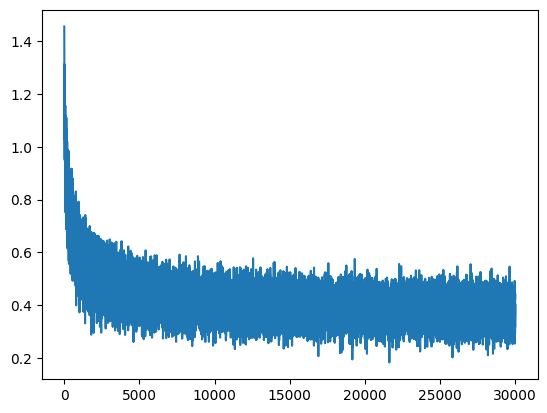

In [26]:
plt.plot(stepi, lossi)

In [27]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.4041, grad_fn=<NllLossBackward0>)

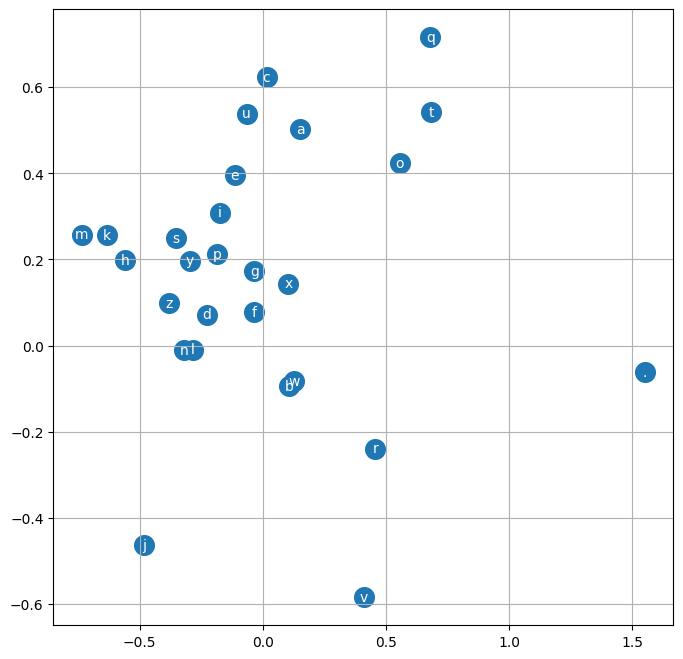

In [28]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [29]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1,block_size,d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

mrittimyah.
keel.
ndylyah.
remmaniejerlee.
adeleonelie.
shy.
remleighavananannelyziolonea.
nyshebergahimiel.
kenleenel.
ranthony.
ummeylee.
kylynn.
ekgylle.
mysheyah.
hyl.
kalyah.
khaudlel.
juren.
tre.
kaviahel.
